# SVM Classification: Anime 'Hit' Analysis

This notebook provides a complete pipeline for exploring the MyAnimeList dataset and training an SVM classifier. It uses the refactored modular structure in the `src/` directory.

## 1. Data Loading & Exploration
We use the `src.data_loader` to fetch the dataset.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import kagglehub
import joblib
import sklearn
import os
import sys

# Ensure the local modules are importable
sys.path.append(os.getcwd())

from src.data_loader import load_data
from src.preprocessing import clean_data

# Load and clean data
df_raw = load_data()
df, _ = clean_data(df_raw)  # Unpacking the tuple (df, medians)
df['target_name'] = df['target'].map({1: 'Hit', 0: 'Standard'})

print(f"Dataset Summary:")
print(df['target_name'].value_counts(normalize=True))

Downloading/Loading dataset...
Successfully loaded 19311 records.
Cleaning data...
Dataset Summary:
target_name
Standard    0.93706
Hit         0.06294
Name: proportion, dtype: float64


### Visualizing Feature Distributions
We use violin plots to see how feature distributions differ between Hits and Standard releases.

C:\Users\HP\AppData\Local\Temp\ipykernel_20904\2987379562.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='target_name', y='members', data=df, palette='muted')
C:\Users\HP\AppData\Local\Temp\ipykernel_20904\2987379562.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='target_name', y='popularity', data=df, palette='muted')


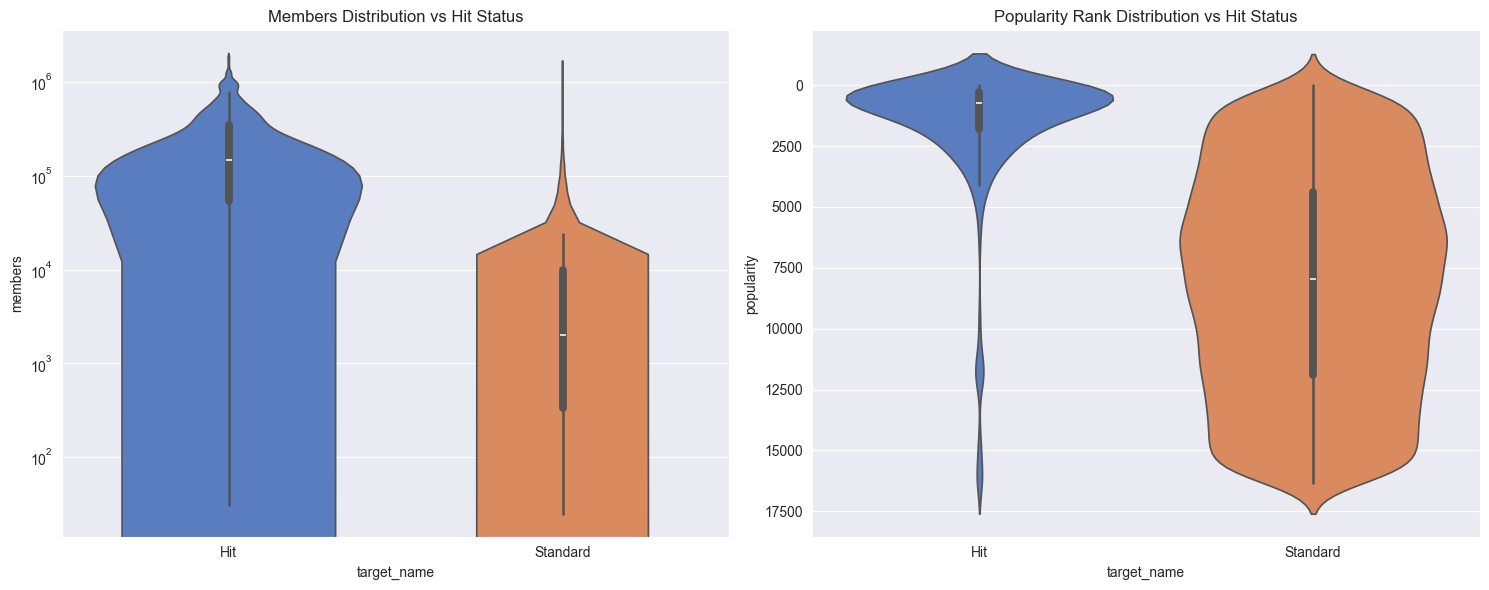

In [2]:
plt.figure(figsize=(15, 6))
plt.subplot(1, 2, 1)
sns.violinplot(x='target_name', y='members', data=df, palette='muted')
plt.title('Members Distribution vs Hit Status')
plt.yscale('log')

plt.subplot(1, 2, 2)
sns.violinplot(x='target_name', y='popularity', data=df, palette='muted')
plt.title('Popularity Rank Distribution vs Hit Status')
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

### Multivariate Analysis
Checking the density of Hits using JointPlots.

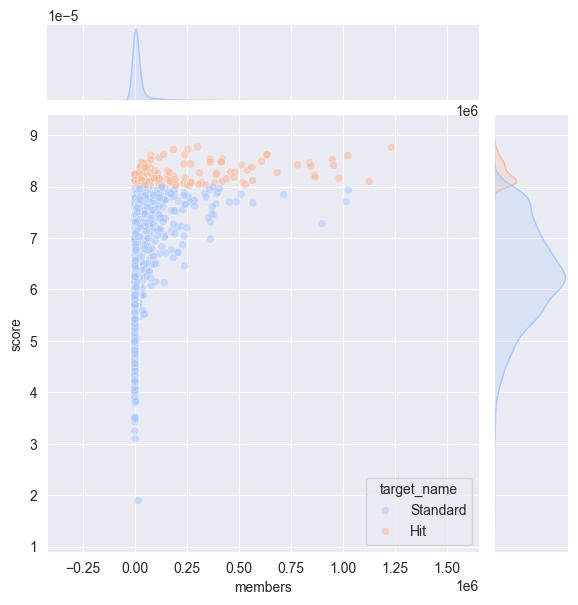

In [3]:
sns.jointplot(x='members', y='score', data=df.sample(2000), hue='target_name', alpha=0.5, palette='coolwarm')
plt.show()

## 2. Model Training & Evaluation
Now we use the `src.preprocessing`, `src.train`, and `src.evaluate` modules to build the classification model.

In [4]:
from src.preprocessing import preprocess_training_data
from src.train import train_and_select_best
from src.evaluate import calculate_metrics, plot_comparison_curves, plot_decision_boundary

# 1. Preprocess
X_train, X_test, y_train, y_test, feature_names = preprocess_training_data(df_raw)

# 2. Train & Select Best Model (PR-AUC)
results, best_kernel = train_and_select_best(X_train, y_train, X_test, y_test, kernels=['rbf', 'poly'])

# 3. Metrics for Best Model
best_results = results[best_kernel]
metrics = calculate_metrics(y_test, best_results['model'].predict(X_test), best_results['y_scores'])

print(f"\n--- Best Model ({best_kernel.upper()}) Metrics ---")
print(f"Accuracy: {metrics['accuracy']:.4f}")
print(f"PR-AUC: {metrics['pr_auc']:.4f}")
print("\nClassification Report:\n", metrics['report'])

Preprocessing training data...
Cleaning data...
Preprocessors and training medians saved to models/
Training SVM with rbf kernel...
Kernel: rbf | PR-AUC: 0.8575
Training SVM with poly kernel...
Kernel: poly | PR-AUC: 0.7826

Best Model: RBF with PR-AUC: 0.8575
Best model saved to models\best_svm_model.pkl

--- Best Model (RBF) Metrics ---
Accuracy: 0.9429
PR-AUC: 0.8575

Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.95      0.97      3511
           1       0.53      0.91      0.67       236

    accuracy                           0.94      3747
   macro avg       0.76      0.93      0.82      3747
weighted avg       0.96      0.94      0.95      3747



### Visualizing Performance
We can plot the curves and decision boundary directly in the notebook.

Comparison curves saved to notebook_comparison.png


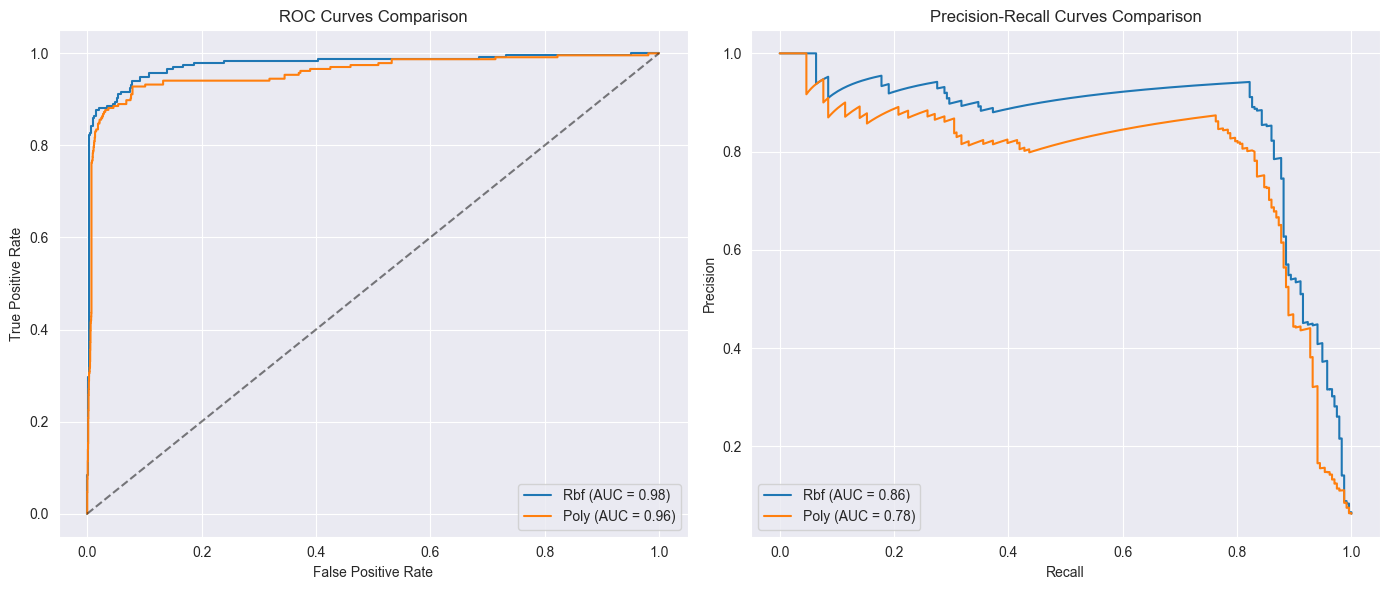

Generating decision boundary plot for rbf kernel...
Decision boundary plot saved to notebook_boundary.png


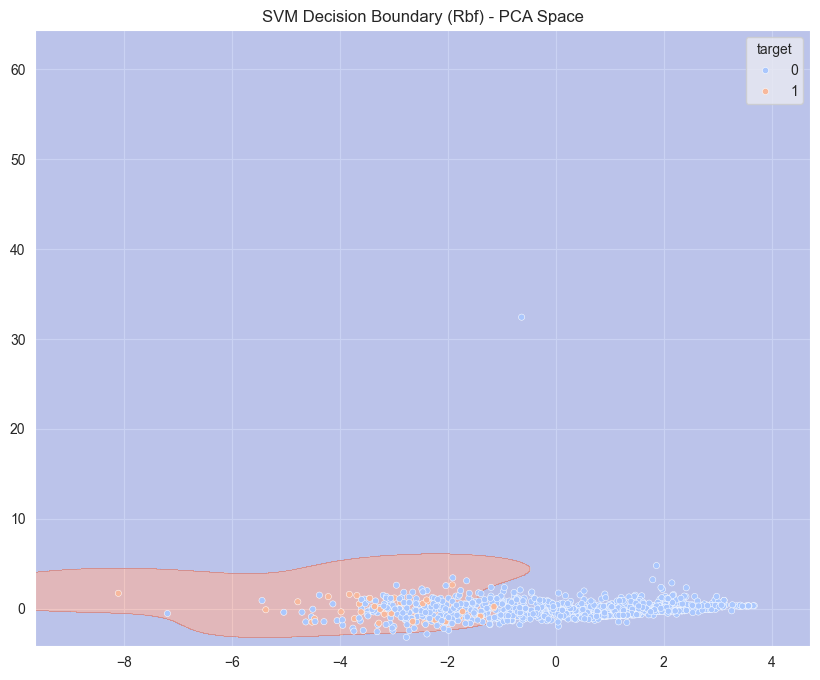

In [5]:
# Plot Comparison Curves
plot_comparison_curves(y_test, results, filename='notebook_comparison.png')
plt.show()

# Plot Decision Boundary for the Best Model
plot_decision_boundary(X_test, y_test, kernel=best_kernel, filename='notebook_boundary.png')
plt.show()